# 02 — Feature extraction

```bash
python -m src.preprocessing
python -m src.features extract
python -m src.features augment
```

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().parent if (Path.cwd().parent / "src").exists() else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.config import FEATURES_DIR, PROCESSED_ROOT

LANG = "kidawida"

In [2]:
# Processed training sample
p = PROCESSED_ROOT / LANG / "manifests" / "train_processed.tsv"
if p.exists():
    display(pd.read_csv(p, sep="\t")[["audio_path", "transcript", "duration_sec"]].head())
else:
    print("Run: python -m src.preprocessing")

,audio_path,transcript,duration_sec
0,audio/train/common_voice_dav_40688698.wav,wakarilwa na kumarwa ni izi toe.,4.5435
1,audio/train/common_voice_dav_41079948.wav,"w'ana ndew'iuzwa, w'anekwa mundu ulele.",4.4355
2,audio/train/common_voice_dav_40572995.wav,mka obanda sa mlamba.,7.0275
3,audio/train/common_voice_dav_40572954.wav,jiwike kula na mwai wa w'andu.,4.0035
4,audio/train/common_voice_dav_41052705.wav,mundu wa w'omi wapo oka na mka mzima cha shighadi,6.4155


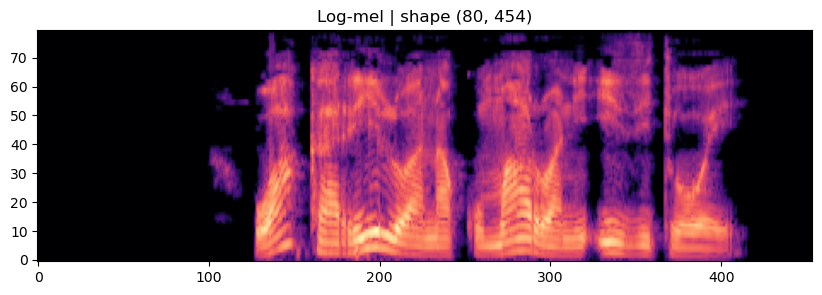

In [3]:
# Log-mel spectrogram plot
feat_manifest = FEATURES_DIR / LANG / "train_features.tsv"
if feat_manifest.exists():
    df = pd.read_csv(feat_manifest, sep="\t")
    mel = np.load(FEATURES_DIR / LANG / df.iloc[0]["feature_path"])
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.imshow(mel, aspect="auto", origin="lower", cmap="magma")
    ax.set_title(f"Log-mel | shape {mel.shape}")
    fig.savefig(ROOT / "outputs" / "figures" / "sample_spectrogram.png", dpi=120)
    plt.show()
else:
    print("Run: python -m src.features extract")

In [4]:
# Augmented vs original count
aug = FEATURES_DIR / LANG / "train_augmented.tsv"
if feat_manifest.exists() and aug.exists():
    display(pd.DataFrame({
        "set": ["original", "augmented"],
        "clips": [len(pd.read_csv(feat_manifest, sep="\t")), len(pd.read_csv(aug, sep="\t"))],
    }))
else:
    print("Run: python -m src.features augment")

,set,clips
0,original,1639
1,augmented,1639
